# Disaster Tweets — fastText-style classifier, trained from scratch

Joulin et al. (2016), *Bag of Tricks for Efficient Text Classification*: represent a tweet as the **average of the embeddings of
its words and hashed word-bigrams**, then classify linearly,

$$\hat y=\sigma\Big(\mathbf w^\top\tfrac1{|d|}\textstyle\sum_{g\in d}\mathbf e_g+b\Big),\qquad g\in\{\text{unigrams}\}\cup\{\text{hash}(w_i,w_{i+1})\bmod B\}.$$

This is a low-rank linear model with **no pre-trained weights**: embeddings are initialised randomly and learned on the 6k
training tweets of each fold. Bigrams are hashed into $B=50{,}000$ buckets (CRC-32, deterministic) so that word order enters
without a huge vocabulary. The keyword token is the first word of every tweet.

**Protocol.** Same five folds as every other method. Inside each fold's training rows, 10% is held out as an *inner* set that
selects the best epoch (lowest log loss) and stops training; the outer validation fold is recorded every epoch as a trace and
**never selects anything**. Two seeds per fold are averaged. Training collects statistics only; figures are drawn afterwards.

In [1]:
import time, json, os
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.calibration import calibration_curve
import nlp_common as N, nlp_dl as D
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52", "#55A868", "#8172B2"]
dev = "cuda" if torch.cuda.is_available() else "cpu"; print("device:", dev, torch.cuda.get_device_name(0) if dev == "cuda" else "")
train, test, folds = N.load(); y = train.target.values; X, TX = N.model_text(train), N.model_text(test)
import train_dl as TD
SPEC = TD.SPECS["fasttext"]; CFG, DIM, DROP, B, SEEDS = SPEC["cfg"], SPEC["dim"], SPEC["dropout"], SPEC["buckets"], SPEC["seeds"]; print("config:", CFG, "dim", DIM, "dropout", DROP, "buckets", B, "seeds", SEEDS)

device: cuda NVIDIA GeForce GTX 1650 Ti
config: {'lr': 0.002, 'wd': 0.01, 'batch': 128, 'epochs': 40, 'patience': 6, 'lr_patience': 2} dim 16 dropout 0.5 buckets 50000 seeds [0, 1]


## Training (statistics only)

Training is done by `train_dl.py fasttext`: resumable, one saved record per (fold, seed) run (per-epoch statistics, predictions,
weights), and no new run is started once its time budget is used. This notebook assembles the saved runs; nothing is retrained here.

In [2]:
res = TD.assemble("fasttext"); assert res is not None, "training incomplete: run `python3 train_dl.py fasttext` again"
oof_s, test_s, runs = res; oof_logit, test_logit = oof_s.mean(0), test_s.mean(0); ev = N.evaluate(y, oof_logit, folds)
tot = sum(h["seconds"] for r in runs for h in r["history"]); print(f"fastText: AUC {ev['auc']:.4f}  F1 {ev['f1']:.4f} {np.round(ev['f1_ci95'], 4)}  ({len(runs)} runs, {tot:.0f}s of training on the GPU)")
single = [N.evaluate(y, oof_s[i], folds, n_boot=20) for i in range(len(SEEDS))]; print("single-seed F1:", [round(e["f1"], 4) for e in single], "AUC:", [round(e["auc"], 4) for e in single])
N.save_method("fasttext", oof_logit, test_logit, dict(kind="logit", dim=DIM, dropout=DROP, buckets=B, seeds=SEEDS, cfg=CFG, **ev))
d0 = TD.prepare_fold("fasttext", 0, train, test, folds, dev); models = dict(m=TD.load_model("fasttext", d0), V=d0["V"])

fastText: AUC 0.8580  F1 0.7571 [0.7458 0.7682]  (10 runs, 44s of training on the GPU)


single-seed F1: [0.7568, 0.7572] AUC: [0.8578, 0.858]


## In-training statistics

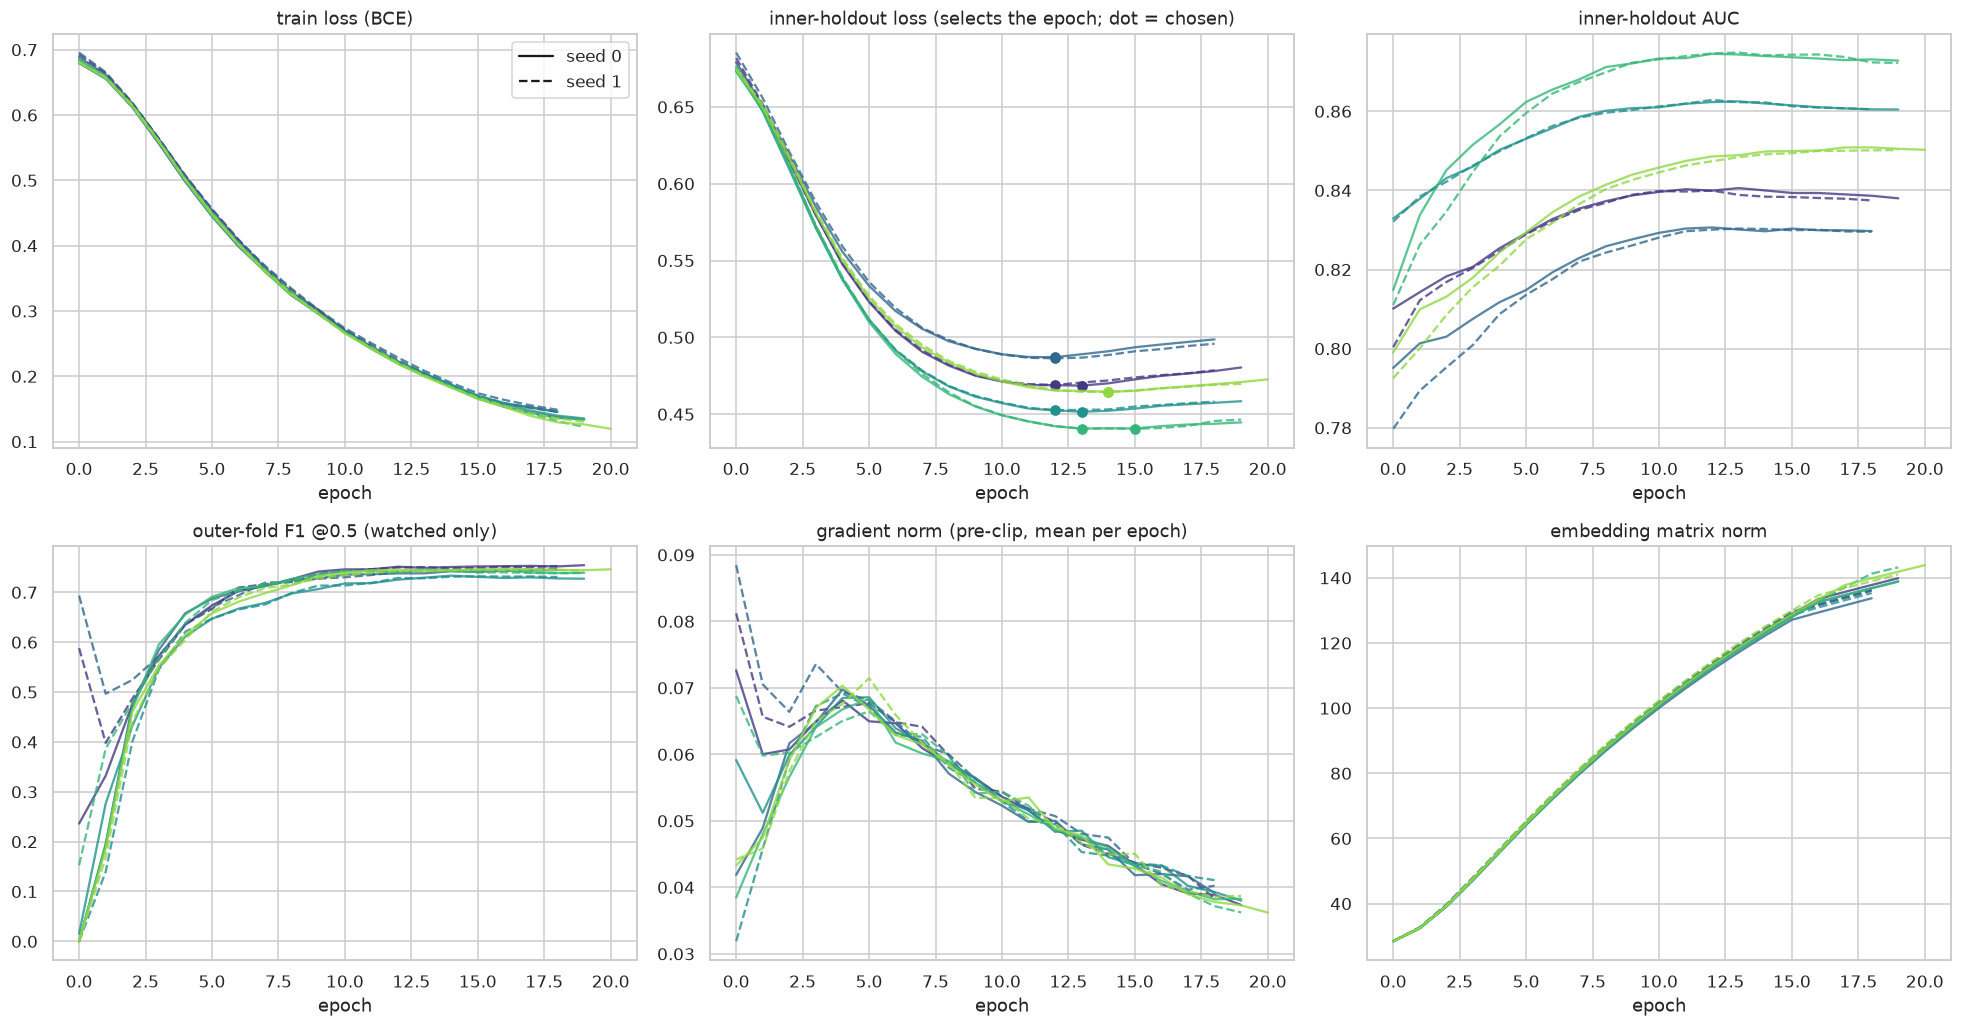

In [3]:
H = pd.concat([pd.DataFrame(r["history"]).assign(fold=r["fold"], seed=r["seed"], best=r["best_epoch"]) for r in runs])
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5)); cs = sns.color_palette("viridis", 5)
for (k, s), g in H.groupby(["fold", "seed"]):
    ls = "-" if s == 0 else "--"; c = cs[k]
    axes[0, 0].plot(g.epoch, g.train_loss, ls, color=c, alpha=.8); axes[0, 1].plot(g.epoch, g.inner_loss, ls, color=c, alpha=.8)
    axes[0, 2].plot(g.epoch, g.inner_auc, ls, color=c, alpha=.8); axes[1, 0].plot(g.epoch, g.mon_f1, ls, color=c, alpha=.8)
    axes[1, 1].plot(g.epoch, g.grad_norm, ls, color=c, alpha=.8); axes[1, 2].plot(g.epoch, g.emb_norm, ls, color=c, alpha=.8)
    axes[0, 1].plot(g.best.iloc[0], g.inner_loss.min(), "o", color=c, ms=6)
for ax, t in zip(axes.ravel(), ["train loss (BCE)", "inner-holdout loss (selects the epoch; dot = chosen)", "inner-holdout AUC", "outer-fold F1 @0.5 (watched only)", "gradient norm (pre-clip, mean per epoch)", "embedding matrix norm"]):
    ax.set_title(t); ax.set_xlabel("epoch")
axes[0, 0].plot([], [], "k-", label="seed 0"); axes[0, 0].plot([], [], "k--", label="seed 1"); axes[0, 0].legend()
plt.tight_layout(); plt.savefig("assets/fasttext_01_training_statistics.png", bbox_inches="tight"); plt.show()

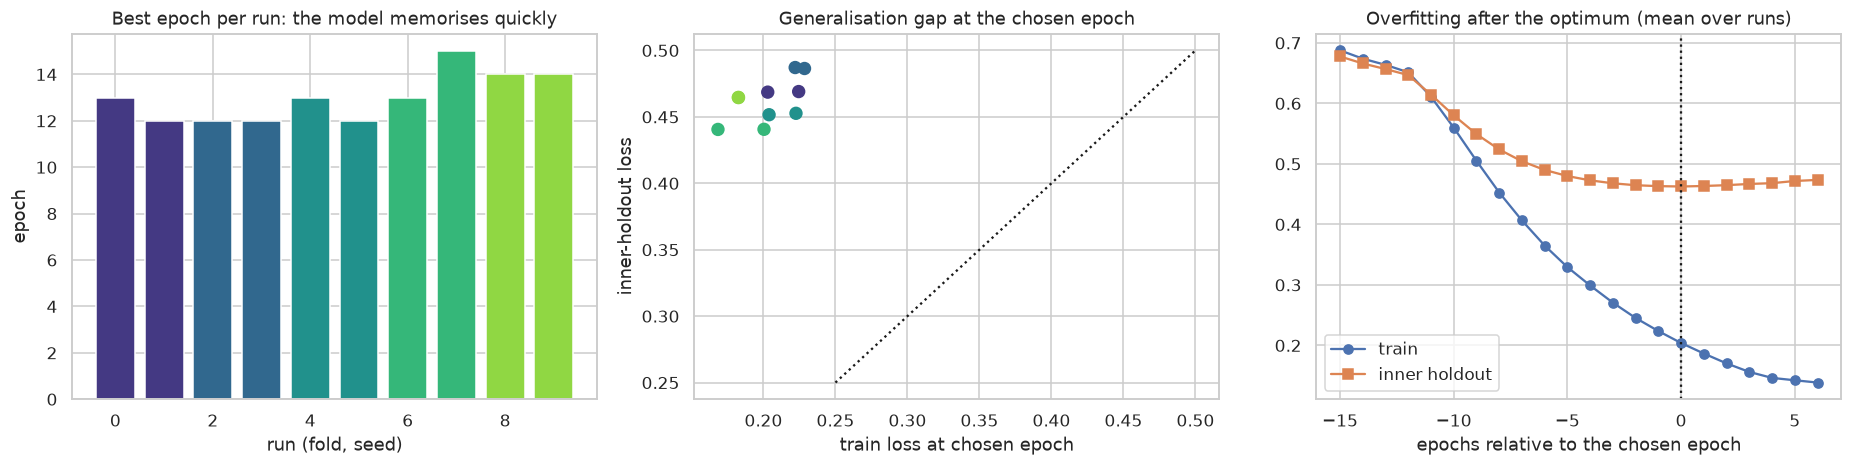

,fold,seed,best_epoch,epochs,seconds,train_loss,inner_loss
0,0,0,13,20,5.2924,0.2030,0.4686
1,0,1,12,19,3.2364,0.2245,0.4690
2,1,0,12,19,3.8787,0.2220,0.4871
3,1,1,12,19,3.7026,0.2285,0.4864
4,2,0,13,20,3.8889,0.2039,0.4516
5,2,1,12,19,3.2755,0.2226,0.4526
6,3,0,13,20,4.4275,0.2004,0.4406
7,3,1,15,20,3.8531,0.1684,0.4405
8,4,0,14,21,4.1322,0.1826,0.4646
9,4,1,14,20,7.8709,0.1827,0.4645


In [4]:
R = pd.DataFrame([dict(fold=r["fold"], seed=r["seed"], best_epoch=r["best_epoch"], epochs=r["n_epochs"], seconds=sum(h["seconds"] for h in r["history"]),
        train_loss=r["history"][r["best_epoch"]]["train_loss"], inner_loss=r["history"][r["best_epoch"]]["inner_loss"]) for r in runs])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
axes[0].bar(range(len(R)), R.best_epoch, color=[cs[f] for f in R.fold]); axes[0].set_xlabel("run (fold, seed)"); axes[0].set_ylabel("epoch"); axes[0].set_title("Best epoch per run: the model memorises quickly")
axes[1].scatter(R.train_loss, R.inner_loss, c=[cs[f] for f in R.fold], s=60); axes[1].plot([0.25, 0.5], [0.25, 0.5], "k:"); axes[1].set_xlabel("train loss at chosen epoch"); axes[1].set_ylabel("inner-holdout loss"); axes[1].set_title("Generalisation gap at the chosen epoch")
last = H[H.epoch <= H.best + 6]; piv = last.assign(rel=last.epoch - last.best).groupby("rel")[["train_loss", "inner_loss"]].mean()
axes[2].plot(piv.index, piv.train_loss, "o-", label="train"); axes[2].plot(piv.index, piv.inner_loss, "s-", label="inner holdout"); axes[2].axvline(0, color="k", ls=":"); axes[2].legend()
axes[2].set_xlabel("epochs relative to the chosen epoch"); axes[2].set_title("Overfitting after the optimum (mean over runs)")
plt.tight_layout(); plt.savefig("assets/fasttext_02_generalisation.png", bbox_inches="tight"); plt.show(); display(R.round(4))

## Post-training analysis

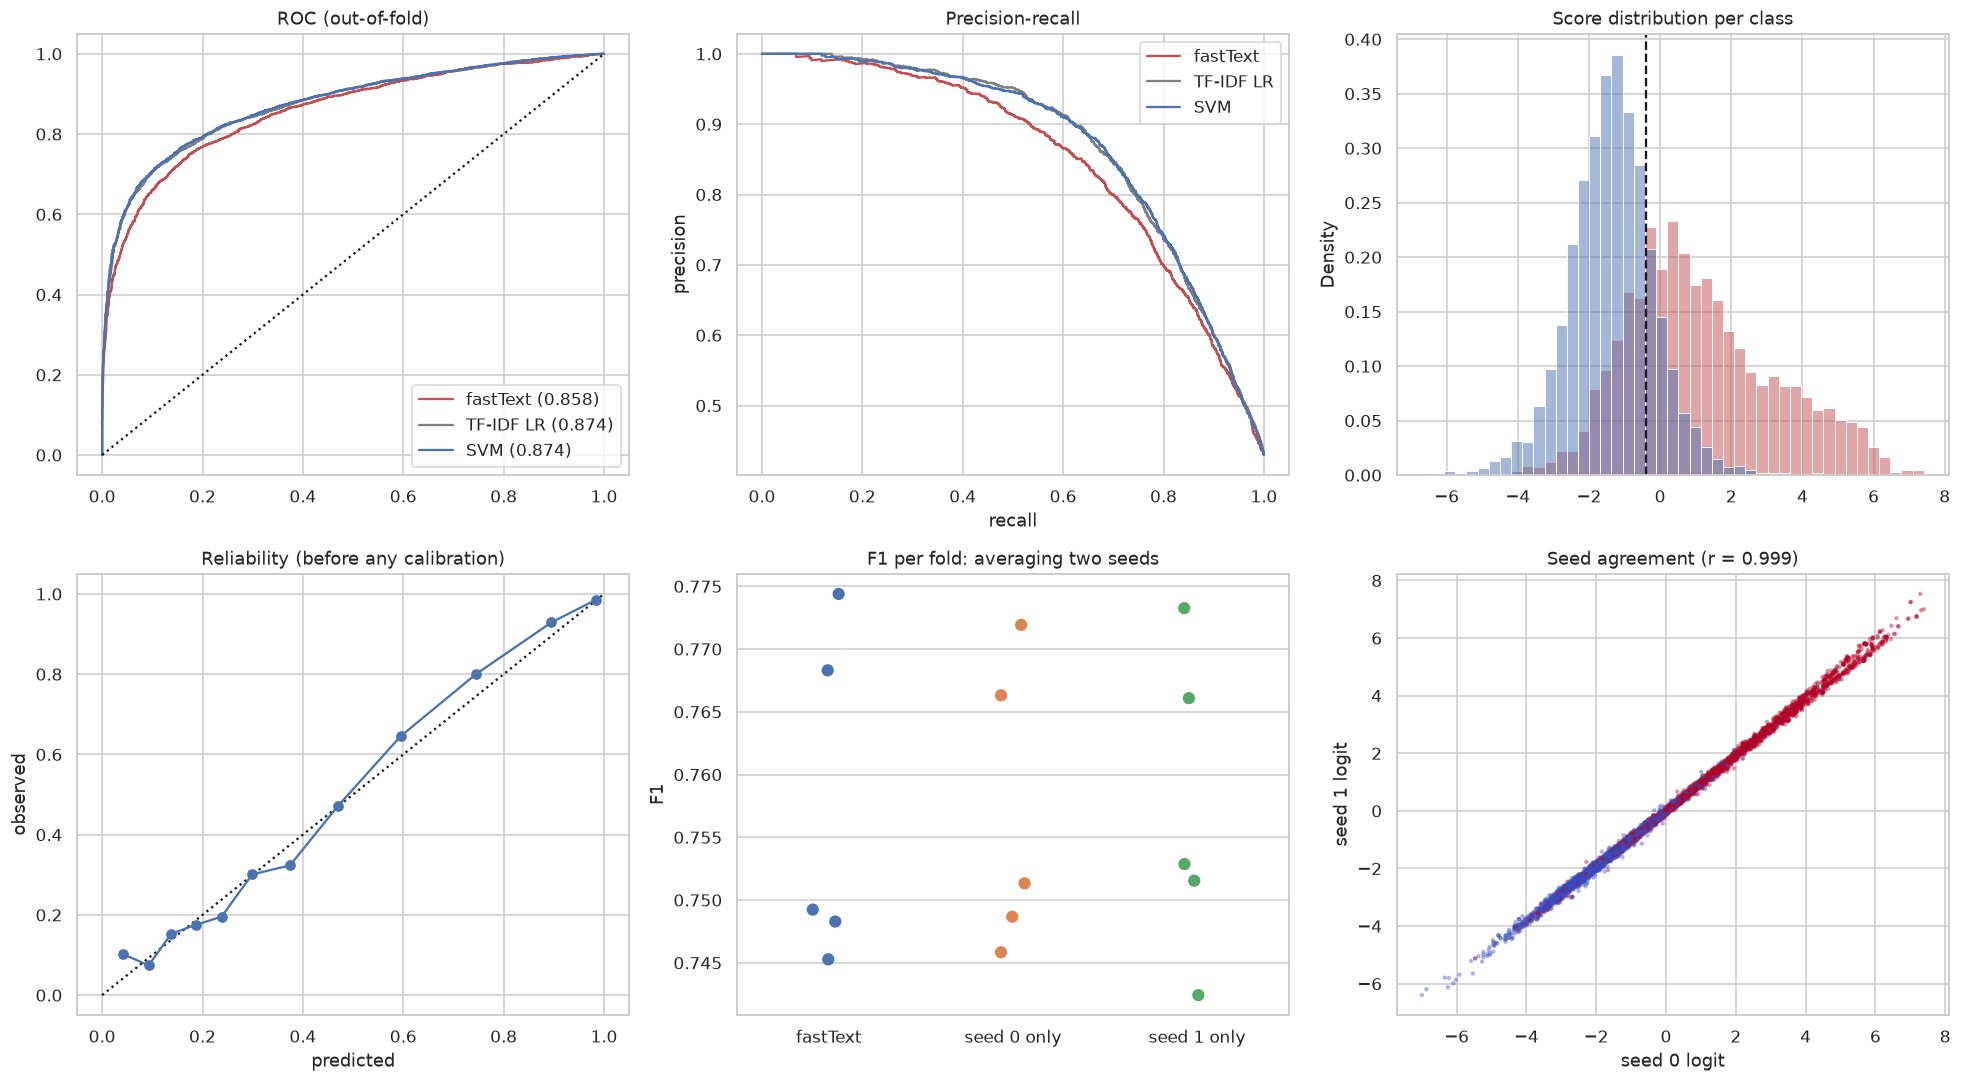

In [5]:
base = np.load("results/v1_tfidf_oof.npy"); sv = N.load_method("svm_cost")[0]; p_ft = N.sigmoid(oof_logit)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for nm, o, c in [("fastText", oof_logit, PAL[1]), ("TF-IDF LR", base, "grey"), ("SVM", sv, PAL[0])]:
    f, t, _ = roc_curve(y, o); axes[0, 0].plot(f, t, color=c, label=f"{nm} ({roc_auc_score(y, o):.3f})")
    pr, rc, _ = precision_recall_curve(y, o); axes[0, 1].plot(rc, pr, color=c, label=nm)
axes[0, 0].plot([0, 1], [0, 1], "k:"); axes[0, 0].legend(); axes[0, 0].set_title("ROC (out-of-fold)"); axes[0, 1].legend(); axes[0, 1].set_title("Precision-recall"); axes[0, 1].set_xlabel("recall"); axes[0, 1].set_ylabel("precision")
sns.histplot(x=oof_logit, hue=y, bins=45, stat="density", common_norm=False, palette=["#4C72B0", "#C44E52"], ax=axes[0, 2], legend=False); axes[0, 2].axvline(ev["threshold"], color="k", ls="--"); axes[0, 2].set_title("Score distribution per class")
fp, mp = calibration_curve(y, p_ft, n_bins=12, strategy="quantile"); axes[1, 0].plot([0, 1], [0, 1], "k:"); axes[1, 0].plot(mp, fp, "o-"); axes[1, 0].set_title("Reliability (before any calibration)"); axes[1, 0].set_xlabel("predicted"); axes[1, 0].set_ylabel("observed")
ff = pd.DataFrame({"fastText": ev["fold_f1"], "seed 0 only": single[0]["fold_f1"], "seed 1 only": single[1]["fold_f1"]}); sns.stripplot(data=ff, ax=axes[1, 1], size=8); axes[1, 1].set_title("F1 per fold: averaging two seeds"); axes[1, 1].set_ylabel("F1")
axes[1, 2].scatter(oof_s[0], oof_s[1], s=4, alpha=.3, c=y, cmap="coolwarm"); axes[1, 2].set_xlabel("seed 0 logit"); axes[1, 2].set_ylabel("seed 1 logit"); axes[1, 2].set_title(f"Seed agreement (r = {np.corrcoef(oof_s[0], oof_s[1])[0,1]:.3f})")
plt.tight_layout(); plt.savefig("assets/fasttext_03_post_training.png", bbox_inches="tight"); plt.show()

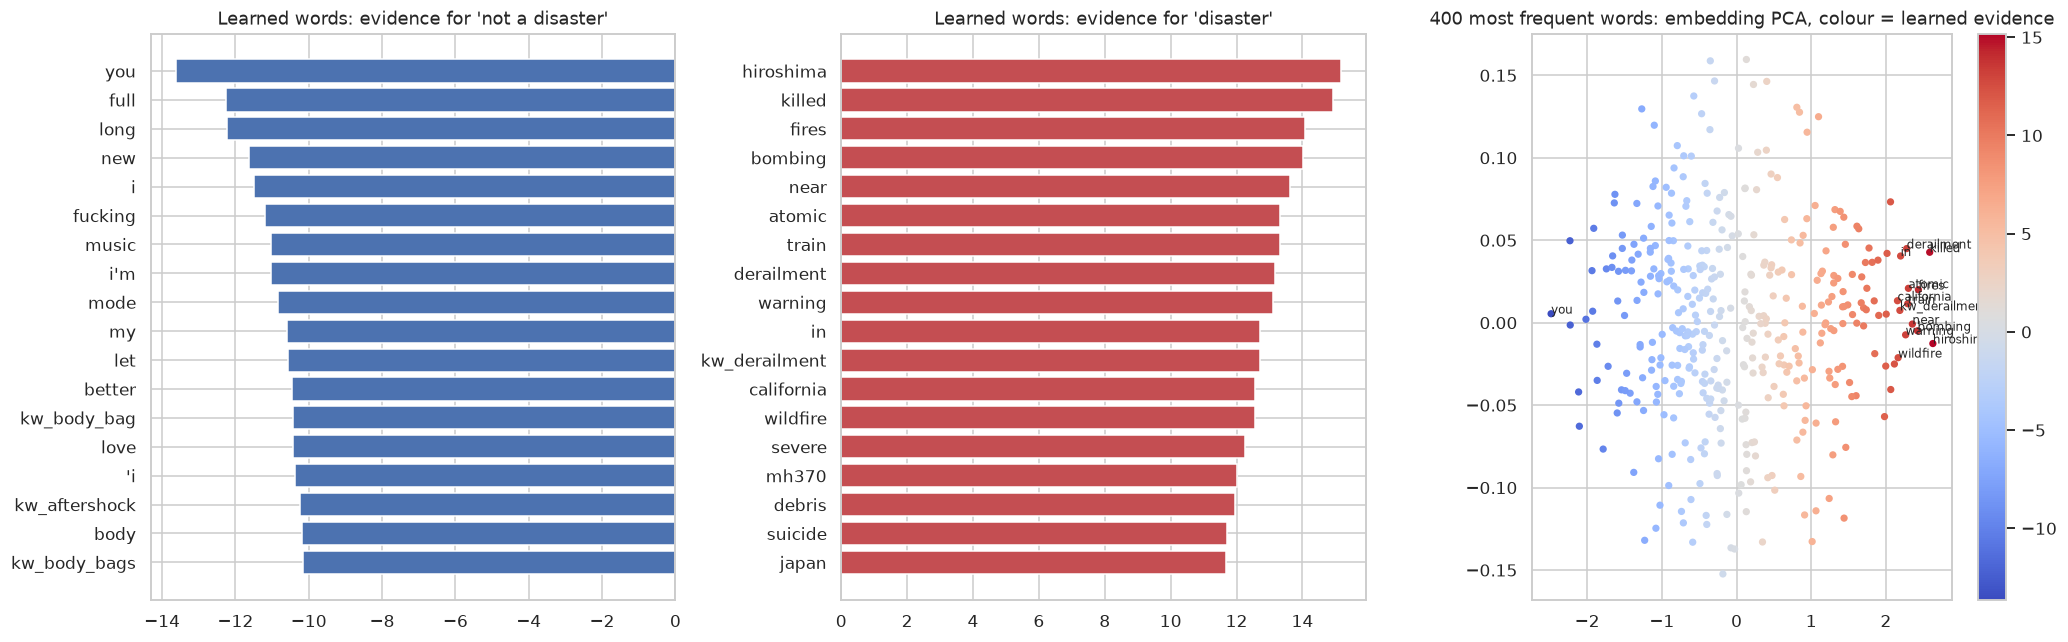

In [6]:
m, V = models["m"], models["V"]; E = m.emb.weight.detach().cpu().numpy(); w = m.out.weight.detach().cpu().numpy().ravel()
contrib = E[: len(V)] @ w; words = np.array(V.itos); freq = np.zeros(len(V))
for t in X.iloc[np.where(folds != 0)[0]]:
    for tok_ in set(t.split()): freq[V.stoi.get(tok_, 1)] += 1
ok = (freq >= 10) & (np.arange(len(V)) > 1); contrib = contrib - np.average(contrib[ok], weights=freq[ok]); o = np.argsort(contrib[ok]); nm_, cc = words[ok][o], contrib[ok][o]
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
axes[0].barh(nm_[:18][::-1], cc[:18][::-1], color=PAL[0]); axes[0].set_title("Learned words: evidence for 'not a disaster'"); axes[1].barh(nm_[-18:], cc[-18:], color=PAL[1]); axes[1].set_title("Learned words: evidence for 'disaster'")
top = np.argsort(-freq)[2:402]; P = PCA(2, random_state=0).fit_transform(E[top]); sc = axes[2].scatter(P[:, 0], P[:, 1], c=contrib[top], cmap="coolwarm", s=14)
for i in np.argsort(-np.abs(contrib[top]))[:14]: axes[2].annotate(words[top][i], P[i], fontsize=8)
axes[2].set_title("400 most frequent words: embedding PCA, colour = learned evidence"); plt.colorbar(sc, ax=axes[2])
plt.tight_layout(); plt.savefig("assets/fasttext_04_learned_words_embedding.png", bbox_inches="tight"); plt.show()